In [ ]:
install.packages(c("tidyverse", "car", "lmtest", "ggpubr"))
library(tidyverse)
library(car)
library(lmtest)
library(ggpubr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘corrplot’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘zoo’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflic

# **Upload and Import Dataset**

In [ ]:
df <- read.csv("physiological_cycles.csv")

# View structure
str(df)

# Summary
summary(df)

'data.frame':	308 obs. of  26 variables:
 $ Cycle.start.time           : chr  "2026-03-22 23:48:46" "2026-03-22 00:16:15" "2026-03-21 00:53:10" "2026-03-19 22:32:40" ...
 $ Cycle.end.time             : chr  "" "2026-03-22 23:48:46" "2026-03-22 00:16:15" "2026-03-21 00:53:10" ...
 $ Cycle.timezone             : chr  "UTC-05:00" "UTC-05:00" "UTC-05:00" "UTC-05:00" ...
 $ Recovery.score..           : int  58 89 61 54 48 35 29 65 84 60 ...
 $ Resting.heart.rate..bpm.   : int  69 64 70 74 74 75 74 69 72 73 ...
 $ Heart.rate.variability..ms.: int  29 38 30 30 28 24 21 37 42 35 ...
 $ Skin.temp..celsius.        : num  34.5 34 34.4 34.6 35 ...
 $ Blood.oxygen..             : num  97.3 96.3 95.3 95.8 98.8 ...
 $ Day.Strain                 : num  NA 15.6 4.5 16.9 15.9 14.9 15.8 16.9 6.7 7.2 ...
 $ Energy.burned..cal.        : int  NA 2678 1850 2826 2779 2506 2801 3219 1523 1805 ...
 $ Max.HR..bpm.               : int  NA 157 129 167 170 154 162 163 151 149 ...
 $ Average.HR..bpm.           : int

 Cycle.start.time   Cycle.end.time     Cycle.timezone     Recovery.score..
 Length:308         Length:308         Length:308         Min.   : 1.00   
 Class :character   Class :character   Class :character   1st Qu.:45.00   
 Mode  :character   Mode  :character   Mode  :character   Median :61.00   
                                                          Mean   :58.75   
                                                          3rd Qu.:78.00   
                                                          Max.   :97.00   
                                                          NA's   :2       
 Resting.heart.rate..bpm. Heart.rate.variability..ms. Skin.temp..celsius.
 Min.   :61.00            Min.   :15.00               Min.   :30.55      
 1st Qu.:67.00            1st Qu.:31.00               1st Qu.:32.70      
 Median :70.00            Median :35.00               Median :33.48      
 Mean   :70.58            Mean   :35.63               Mean   :33.29      
 3rd Qu.:73.00            3rd 

In [ ]:
colnames(df)

[1] "Cycle.start.time"            "Cycle.end.time"             
 [3] "Cycle.timezone"              "Recovery.score.."           
 [5] "Resting.heart.rate..bpm."    "Heart.rate.variability..ms."
 [7] "Skin.temp..celsius."         "Blood.oxygen.."             
 [9] "Day.Strain"                  "Energy.burned..cal."        
[11] "Max.HR..bpm."                "Average.HR..bpm."           
[13] "Sleep.onset"                 "Wake.onset"                 
[15] "Sleep.performance.."         "Respiratory.rate..rpm."     
[17] "Asleep.duration..min."       "In.bed.duration..min."      
[19] "Light.sleep.duration..min."  "Deep..SWS..duration..min."  
[21] "REM.duration..min."          "Awake.duration..min."       
[23] "Sleep.need..min."            "Sleep.debt..min."           
[25] "Sleep.efficiency.."          "Sleep.consistency.."

# **Data Cleaning**

In [ ]:
install.packages("janitor")
library(janitor)

df <- df %>% clean_names()

colnames(df)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "cycle_start_time"          "cycle_end_time"           
 [3] "cycle_timezone"            "recovery_score"           
 [5] "resting_heart_rate_bpm"    "heart_rate_variability_ms"
 [7] "skin_temp_celsius"         "blood_oxygen"             
 [9] "day_strain"                "energy_burned_cal"        
[11] "max_hr_bpm"                "average_hr_bpm"           
[13] "sleep_onset"               "wake_onset"               
[15] "sleep_performance"         "respiratory_rate_rpm"     
[17] "asleep_duration_min"       "in_bed_duration_min"      
[19] "light_sleep_duration_min"  "deep_sws_duration_min"    
[21] "rem_duration_min"          "awake_duration_min"       
[23] "sleep_need_min"            "sleep_debt_min"           
[25] "sleep_efficiency"          "sleep_consistency"

In [ ]:
# Convert Date + Create Lag

df$cycle_start_time <- as.POSIXct(
  df$cycle_start_time,
  format = "%Y-%m-%d %H:%M:%S",
  tz = "UTC"
)

df <- df %>%
  arrange(cycle_start_time) %>%
  mutate(strain_lag1 = lag(day_strain))

# Remove Missing Key Variables

df <- df %>%
  filter(!is.na(recovery_score),
         !is.na(heart_rate_variability_ms),
         !is.na(resting_heart_rate_bpm),
         !is.na(sleep_efficiency),
         !is.na(sleep_debt_min),
         !is.na(strain_lag1))

dim(df)

[1] 306  27

# **Descriptive Statistics**

Exploratory Analysis of Key Physiological Variables

In [ ]:
df %>%
  select(recovery_score,
         heart_rate_variability_ms,
         resting_heart_rate_bpm,
         sleep_efficiency,
         sleep_debt_min,
         strain_lag1) %>%
  summary()

 recovery_score  heart_rate_variability_ms resting_heart_rate_bpm
 Min.   : 1.00   Min.   :15.00             Min.   :61.00         
 1st Qu.:45.00   1st Qu.:31.00             1st Qu.:67.00         
 Median :61.00   Median :35.00             Median :70.00         
 Mean   :58.75   Mean   :35.63             Mean   :70.58         
 3rd Qu.:78.00   3rd Qu.:41.00             3rd Qu.:73.00         
 Max.   :97.00   Max.   :54.00             Max.   :96.00         
 sleep_efficiency sleep_debt_min    strain_lag1    
 Min.   : 68.00   Min.   :  0.00   Min.   : 0.500  
 1st Qu.: 88.00   1st Qu.: 42.25   1st Qu.: 7.525  
 Median : 92.00   Median : 86.00   Median :10.000  
 Mean   : 90.52   Mean   : 76.57   Mean   : 9.789  
 3rd Qu.: 94.00   3rd Qu.:114.75   3rd Qu.:11.475  
 Max.   :100.00   Max.   :127.00   Max.   :17.200  

In [ ]:
install.packages("Hmisc")
library(Hmisc)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘checkmate’, ‘htmlTable’



Attaching package: ‘Hmisc’


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units




In [ ]:
cor_matrix <- cor(df[, c("recovery_score",
                         "heart_rate_variability_ms",
                         "resting_heart_rate_bpm",
                         "sleep_efficiency")])

round(cor_matrix, 2)


rcorr(as.matrix(df[, c("recovery_score",
                       "heart_rate_variability_ms",
                       "resting_heart_rate_bpm",
                       "sleep_efficiency")]))

,recovery_score,heart_rate_variability_ms,resting_heart_rate_bpm,sleep_efficiency
recovery_score,1.00,0.60,-0.62,-0.10
heart_rate_variability_ms,0.60,1.00,-0.63,-0.03
resting_heart_rate_bpm,-0.62,-0.63,1.00,0.00
sleep_efficiency,-0.10,-0.03,0.00,1.00


                          recovery_score heart_rate_variability_ms
recovery_score                      1.00                      0.60
heart_rate_variability_ms           0.60                      1.00
resting_heart_rate_bpm             -0.62                     -0.63
sleep_efficiency                   -0.10                     -0.03
                          resting_heart_rate_bpm sleep_efficiency
recovery_score                             -0.62            -0.10
heart_rate_variability_ms                  -0.63            -0.03
resting_heart_rate_bpm                      1.00             0.00
sleep_efficiency                            0.00             1.00

n= 306 


P
                          recovery_score heart_rate_variability_ms
recovery_score                           0.0000                   
heart_rate_variability_ms 0.0000                                  
resting_heart_rate_bpm    0.0000         0.0000                   
sleep_efficiency          0.0774         0.6228       

# **Linear Regression**

In [ ]:
model <- lm(recovery_score ~
              heart_rate_variability_ms +
              resting_heart_rate_bpm +
              sleep_efficiency +
              sleep_debt_min +
              strain_lag1,
            data = df)

summary(model)


Call:
lm(formula = recovery_score ~ heart_rate_variability_ms + resting_heart_rate_bpm + 
    sleep_efficiency + sleep_debt_min + strain_lag1, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-69.192  -8.068   1.065  11.055  41.752 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)               183.39543   29.01826   6.320 9.44e-10 ***
heart_rate_variability_ms   1.22116    0.19655   6.213 1.73e-09 ***
resting_heart_rate_bpm     -1.79607    0.25805  -6.960 2.14e-11 ***
sleep_efficiency           -0.42781    0.18366  -2.329   0.0205 *  
sleep_debt_min             -0.03212    0.02435  -1.319   0.1882    
strain_lag1                -0.01942    0.34828  -0.056   0.9556    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 17.45 on 300 degrees of freedom
Multiple R-squared:  0.4703,	Adjusted R-squared:  0.4614 
F-statistic: 53.26 on 5 and 300 DF,  p-value: < 2.2e-16


In [ ]:
model2 <- lm(recovery_score ~
               heart_rate_variability_ms +
               resting_heart_rate_bpm +
               sleep_efficiency,
             data = df)

summary(model2)


Call:
lm(formula = recovery_score ~ heart_rate_variability_ms + resting_heart_rate_bpm + 
    sleep_efficiency, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-68.004  -8.185   2.018  11.061  41.793 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)               185.7634    28.4429   6.531 2.76e-10 ***
heart_rate_variability_ms   1.1800     0.1870   6.311 9.88e-10 ***
resting_heart_rate_bpm     -1.8739     0.2511  -7.464 9.01e-13 ***
sleep_efficiency           -0.4063     0.1829  -2.222    0.027 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 17.44 on 302 degrees of freedom
Multiple R-squared:  0.4672,	Adjusted R-squared:  0.4619 
F-statistic: 88.26 on 3 and 302 DF,  p-value: < 2.2e-16


In [ ]:
# Model Comparison

anova(model, model2)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,300,91303.42,NA,NA,NA,NA
2,302,91839.19,-2,-535.7685,0.8802001,0.4157681


**Recovery vs HRV**

`geom_smooth()` using formula = 'y ~ x'


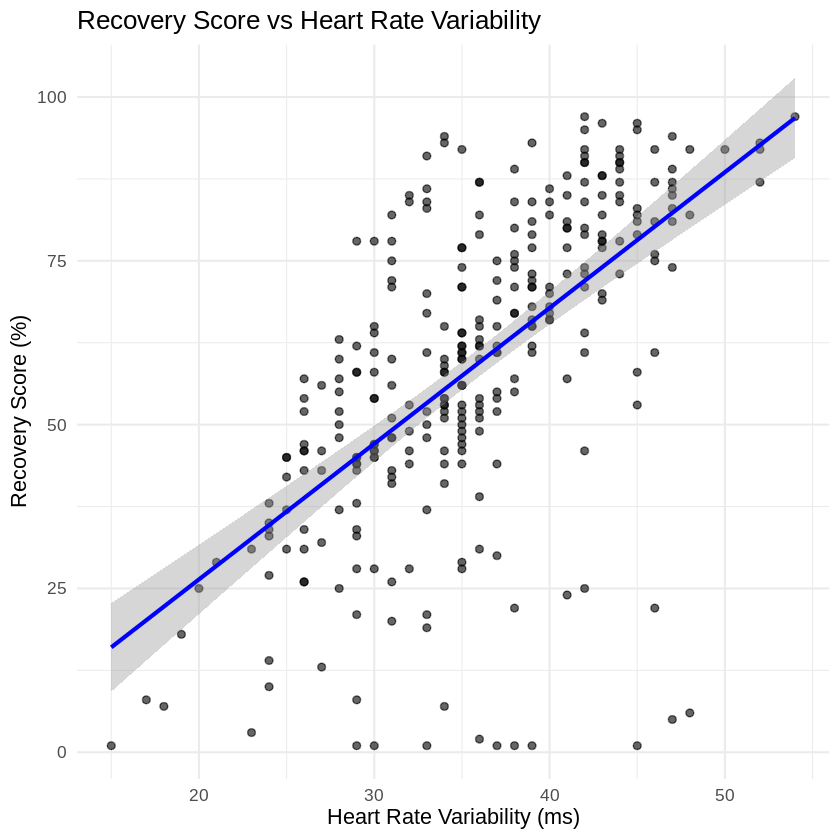

In [ ]:
library(ggplot2)

ggplot(df, aes(x = heart_rate_variability_ms, y = recovery_score)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(
    title = "Recovery Score vs Heart Rate Variability",
    x = "Heart Rate Variability (ms)",
    y = "Recovery Score (%)"
  ) +
  theme_minimal(base_size = 13)

**Recovery vs Resting Heart Rate**

`geom_smooth()` using formula = 'y ~ x'


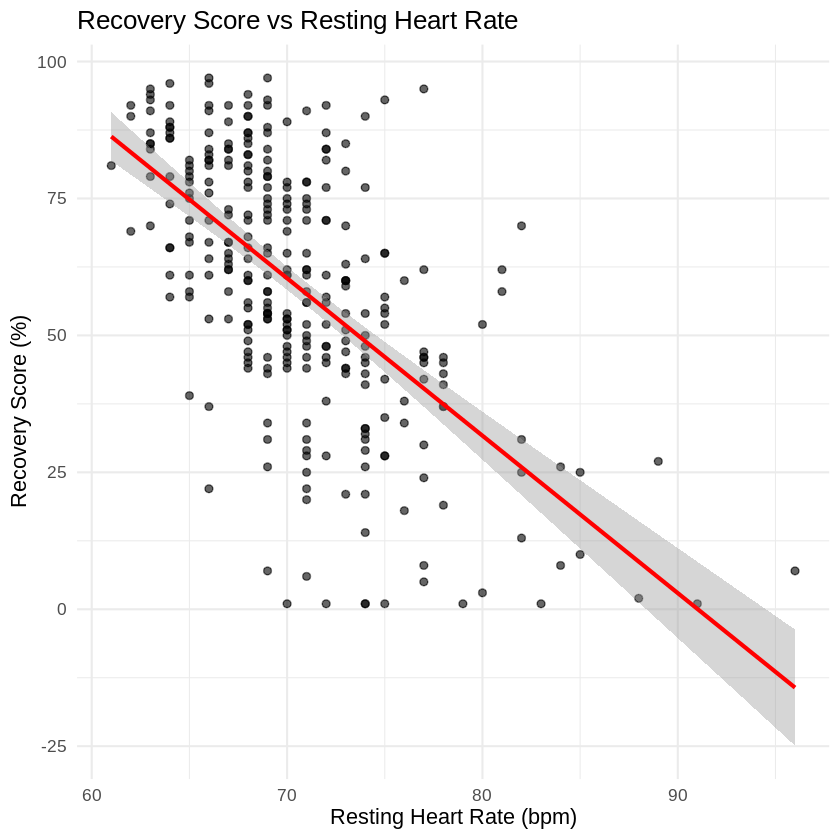

In [ ]:
ggplot(df, aes(x = resting_heart_rate_bpm, y = recovery_score)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(
    title = "Recovery Score vs Resting Heart Rate",
    x = "Resting Heart Rate (bpm)",
    y = "Recovery Score (%)"
  ) +
  theme_minimal(base_size = 13)

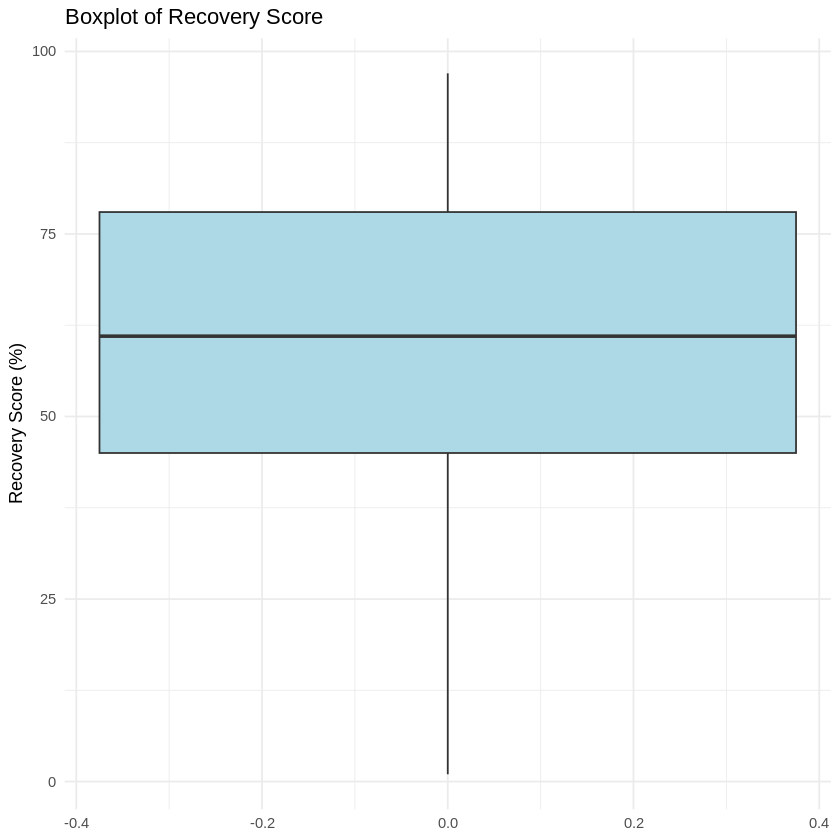

In [ ]:
library(ggplot2)

ggplot(df, aes(y = recovery_score)) +
  geom_boxplot(fill = "lightblue") +
  labs(title = "Boxplot of Recovery Score",
       y = "Recovery Score (%)") +
  theme_minimal()

Running diagnostics and checking assumptions

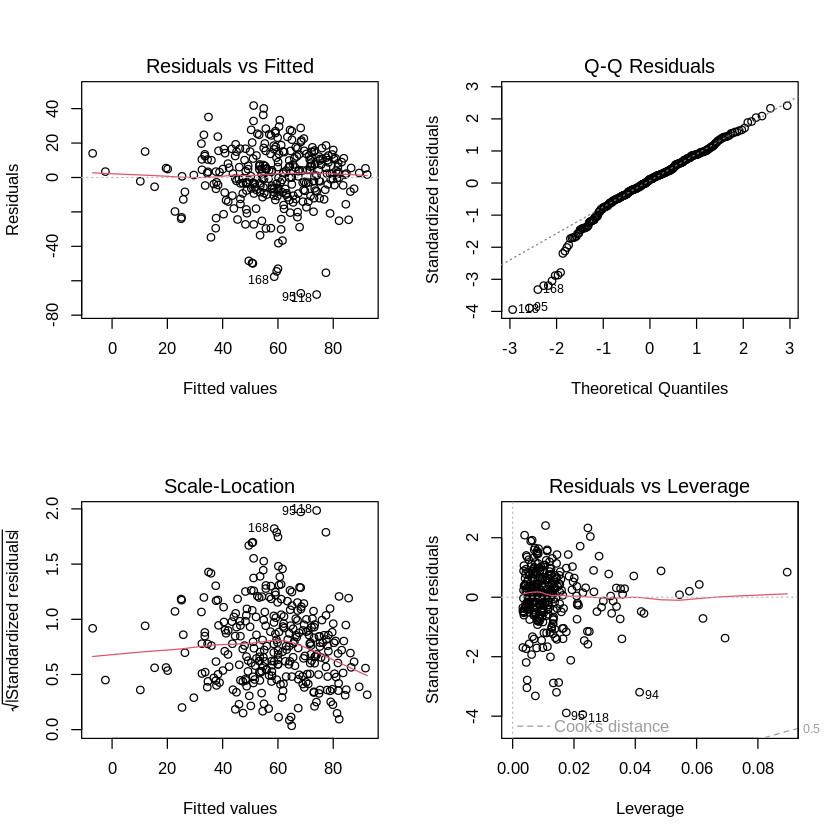

In [ ]:
par(mfrow = c(2,2))
plot(model2)

In [ ]:
shapiro.test(residuals(model2))


	Shapiro-Wilk normality test

data:  residuals(model2)
W = 0.95302, p-value = 2.471e-08


In [ ]:
vif(model2)

heart_rate_variability_ms    resting_heart_rate_bpm          sleep_efficiency 
                 1.670155                  1.668864                  1.001664